# 04 — EnKF + MC Dropout Uncertainty

**Pipeline stage 4 of 7.** Couple the trained LSTM with an Ensemble Kalman Filter
over driver variables (discharge, TN, TP, wind, zos) and combine with Monte-Carlo
dropout to produce probabilistic forecasts with calibrated uncertainty.

**Inputs**
- Sequences (notebook 01) and unscaled test_df (for EnKF observations)
- Trained model from notebook 03
- `shared_config.py`

**Outputs**
- `mc_predictions.npy` — `(N_MC × n_test,)` array of MC-dropout probabilities
- `enkf_metrics.json` — calibration / coverage / sharpness metrics

> Source: Parts 13–15 of the original monolithic notebook.


## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from tensorflow.keras.models import load_model

from sklearn.metrics import (roc_auc_score, brier_score_loss, f1_score,
                             precision_recall_curve)

from shared_config import *
print_config_summary()


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load upstream artifacts

In [2]:
from pipeline_utils import best_f1_threshold, evaluate_probability_stream, load_sequence_artifact, write_json

# Notebook 04 evaluates uncertainty for the EnKF-preprocessed LSTM. The EnKF
# assimilation itself happened in notebook 01 before scaling/sequence creation.
enkf_seq = load_sequence_artifact(ENKF_TUNED_SEQUENCES_PATH if os.path.exists(ENKF_TUNED_SEQUENCES_PATH) else ENKF_SEQUENCES_PATH)
X_train = enkf_seq["X_train"]; y_train = enkf_seq["y_train"]
X_val = enkf_seq["X_val"]; y_val = enkf_seq["y_val"]
X_test = enkf_seq["X_test"]; y_test = enkf_seq["y_test"]
feature_columns = enkf_seq["feature_columns"]
SEQUENCE_LENGTH = enkf_seq["seq_length"]

train_df = pd.read_parquet(ENKF_TRAIN_DF_PATH)
validation_df = pd.read_parquet(ENKF_VAL_DF_PATH)
test_df = pd.read_parquet(ENKF_TEST_DF_PATH)
scaler = joblib.load(ENKF_SCALER_FILENAME)
final_feature_columns_used = joblib.load(ENKF_FEATURE_LIST_FILENAME)

if not os.path.exists(ENKF_LSTM_MODEL_PATH):
    raise FileNotFoundError(f"Missing {ENKF_LSTM_MODEL_PATH}. Run notebook 03 first.")
model = load_model(ENKF_LSTM_MODEL_PATH, compile=False)
trained_model = model

lstm_p_test = np.load(LSTM_TEST_PROBS_PATH) if os.path.exists(LSTM_TEST_PROBS_PATH) else None
lstm_enkf_p_test = np.load(LSTM_ENKF_TEST_PROBS_PATH) if os.path.exists(LSTM_ENKF_TEST_PROBS_PATH) else None

print(f"Loaded EnKF-preprocessed arrays: X_val={X_val.shape}, X_test={X_test.shape}")
print(f"Loaded model: {ENKF_LSTM_MODEL_PATH}")


Loaded EnKF-preprocessed arrays: X_val=(214, 26, 32), X_test=(216, 26, 32)
Loaded model: output_refactored/best_lstm_model_lstm_enkf_preprocessor_tuned_weighted.keras


## Part 13: EnKF Setup

This cell defines the EnsembleKalmanFilter class (assuming it's not in a separate enkf.py file for simplicity here, but importing is better practice) and a function setup_enkf to initialize the filter for the test period. It calculates the initial state, noise matrices (based on the ENKF_NOISE_ESTIMATION setting from Part 1), and identifies the necessary column indices.

Explanation:

1. EnKF Class: Includes the EnsembleKalmanFilter class definition directly in the cell for convenience (assuming it's not imported from enkf.py).

2. setup_enkf Function:

    - Takes necessary configurations and dataframes as input.
    - Initial State/Covariance: Extracts the state vector values (x_initial) from the unscaled test_df at the correct time index (end of the first sequence's lookback period). Calculates an initial covariance matrix P_initial based on relative uncertainty assumptions (these ratios are tunable).
    - Noise Matrices (R, Q): Calculates the observation noise R and process noise Q based on the noise_estimation_method.
    - If 'manual', it uses MANUAL_R_DIAG and MANUAL_Q_DIAG (defined in Part 1).
    - If 'basic_stats', it calculates variances based on the mean (for R) and standard deviation of weekly changes (for Q) from the unscaled train_df, scaled by tunable percentage factors. Includes fallback logic for constant columns.
    - State Indices: Finds the numerical index corresponding to each ENKF_STATE_VARS within the final_feature_columns_used list (which defines the order in the scaled data and LSTM input). This is crucial for correctly updating the LSTM input later.
    - Initialization: Creates an instance of the EnsembleKalmanFilter class using the calculated x_initial, P_initial, and other parameters. Stores the calculated R and Q matrices as attributes of the instance for easy access in the next step.
    - Returns: The initialized enkf object and the list of enkf_state_indices.

4. Main Execution:
    - Checks for prerequisite variables from previous steps.
    - Calls setup_enkf with the appropriate arguments from the configuration (Part 1) and dataframes (Parts 4, 5).
    - Stores the returned enkf_instance and enkf_indices for use in the forecasting loop (Part 12).

After running this cell, the enkf_instance is ready, configured with initial conditions and noise characteristics appropriate for the start of the test period. The enkf_indices list tells us which columns in the LSTM input sequence correspond to the variables being updated by the EnKF.

Saved: output_refactored/matrix_Q_heatmap.png


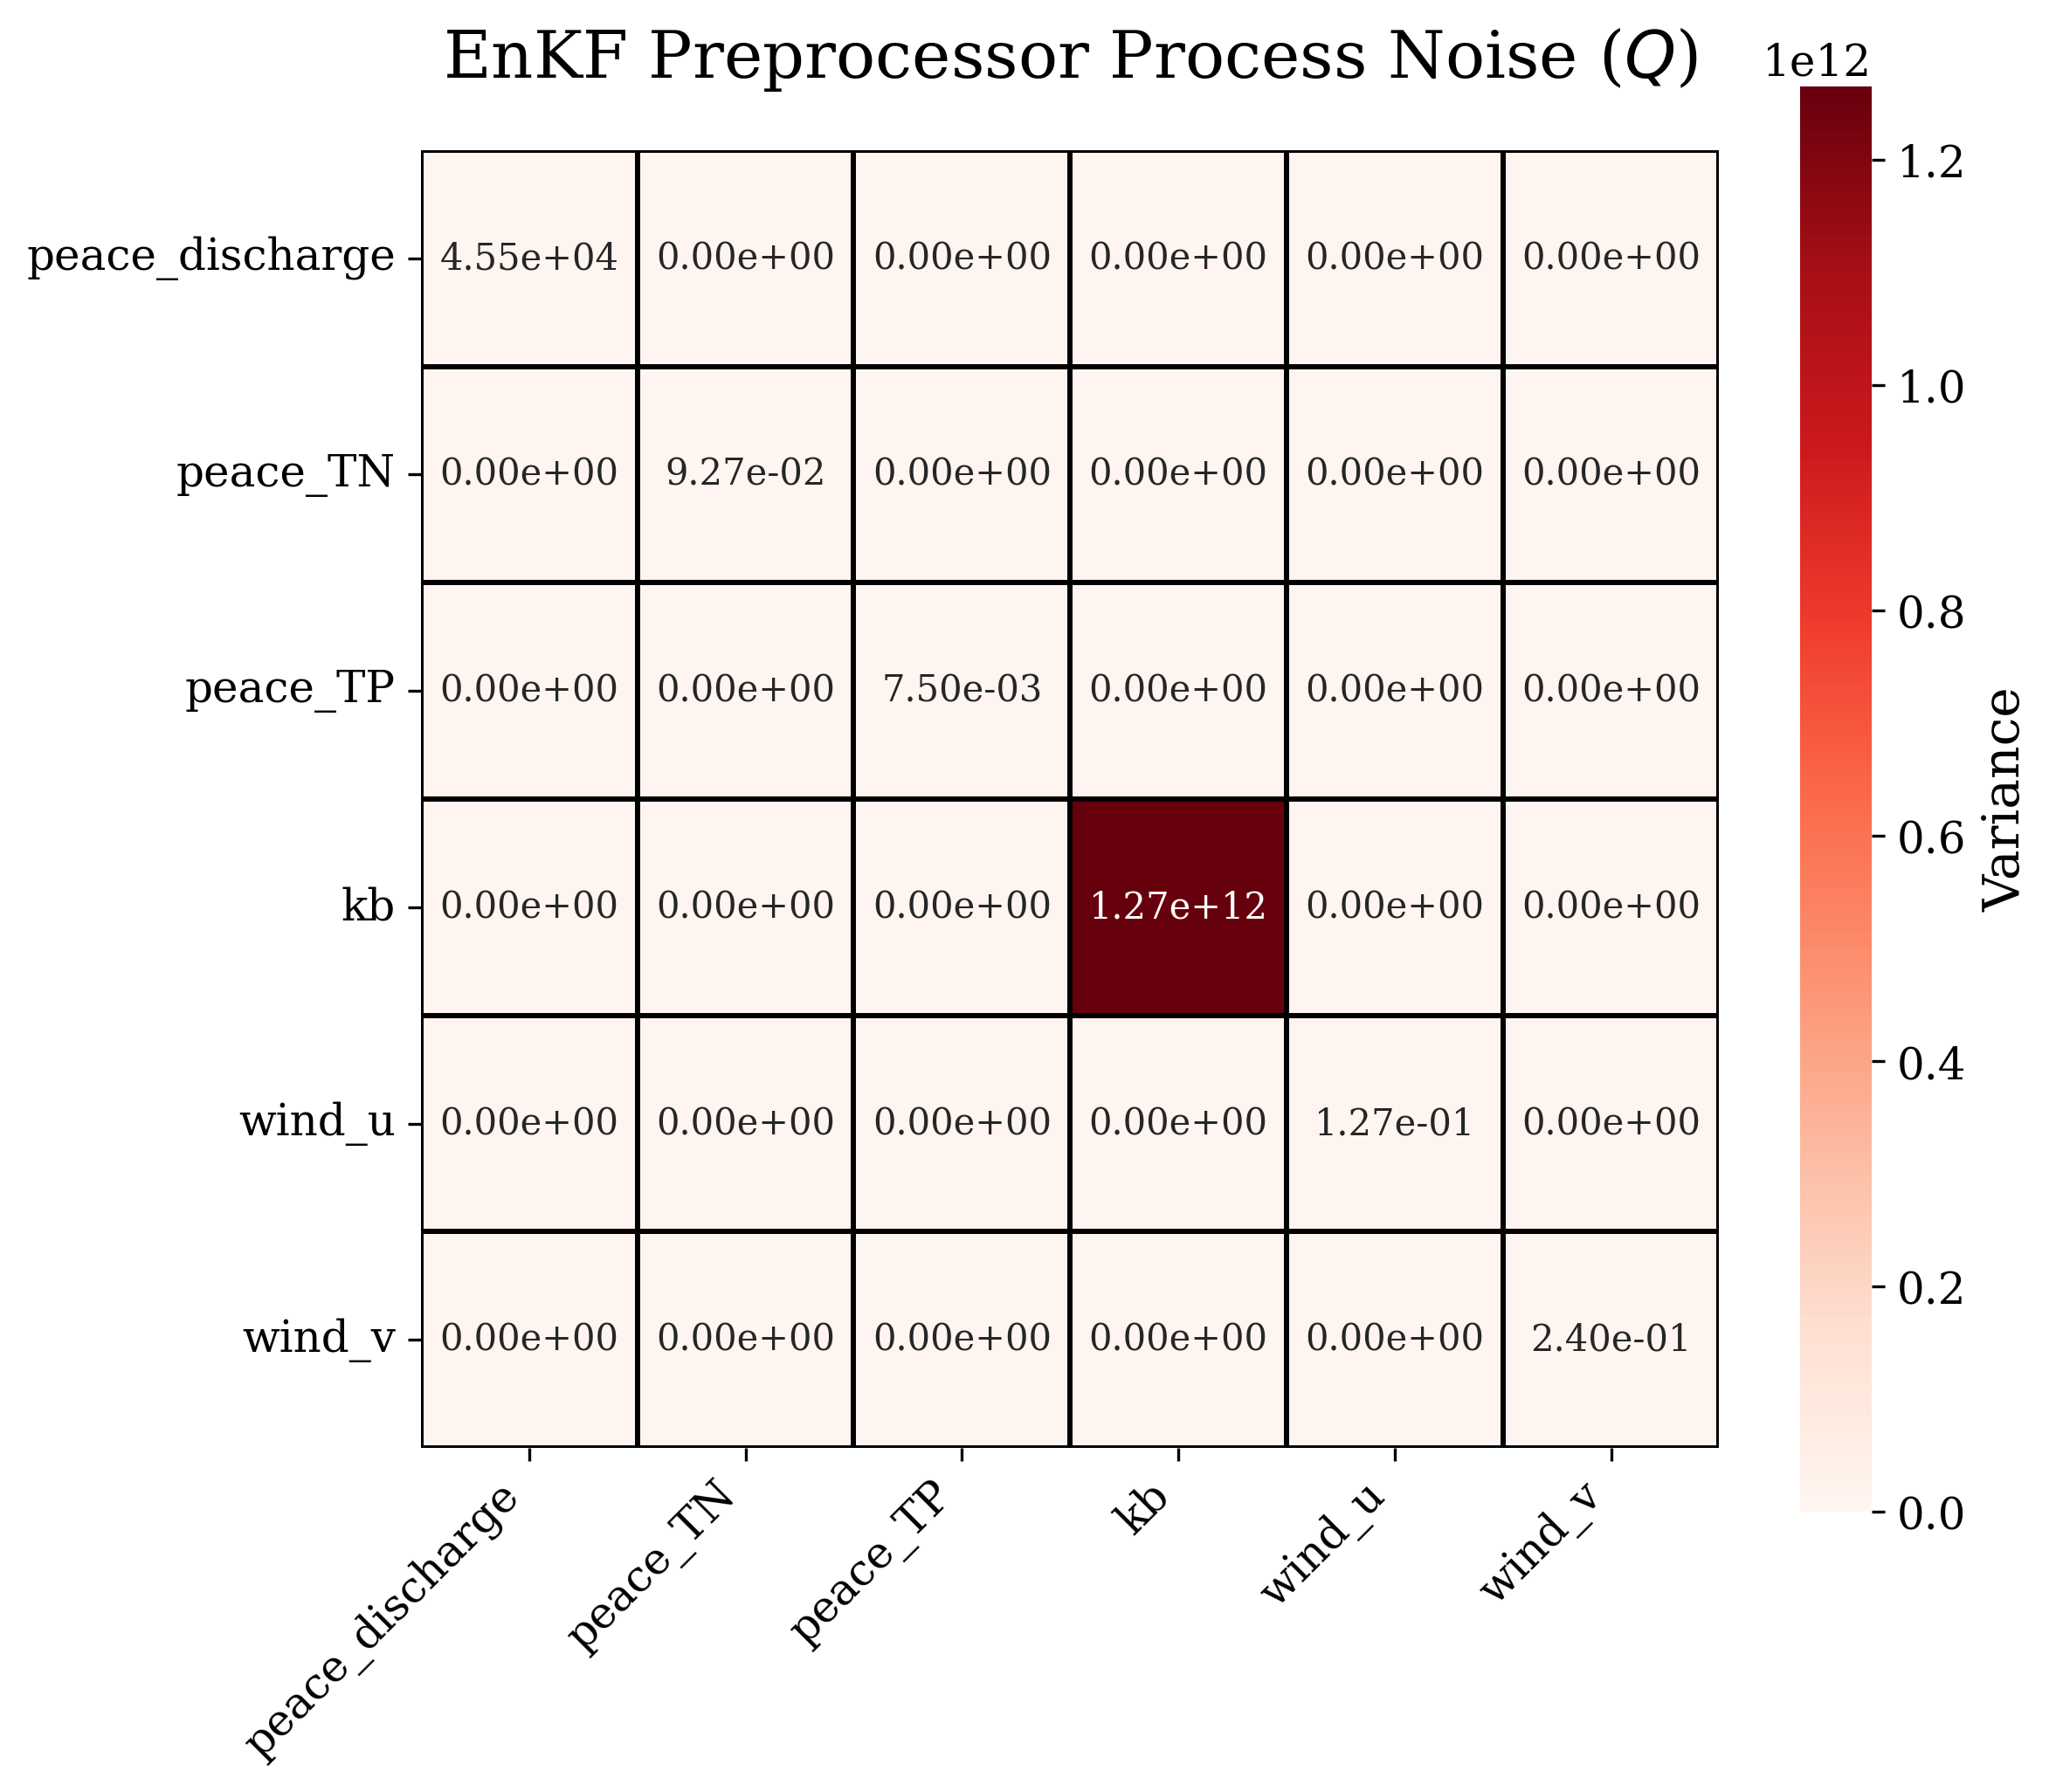

Saved: output_refactored/matrix_R_heatmap.png


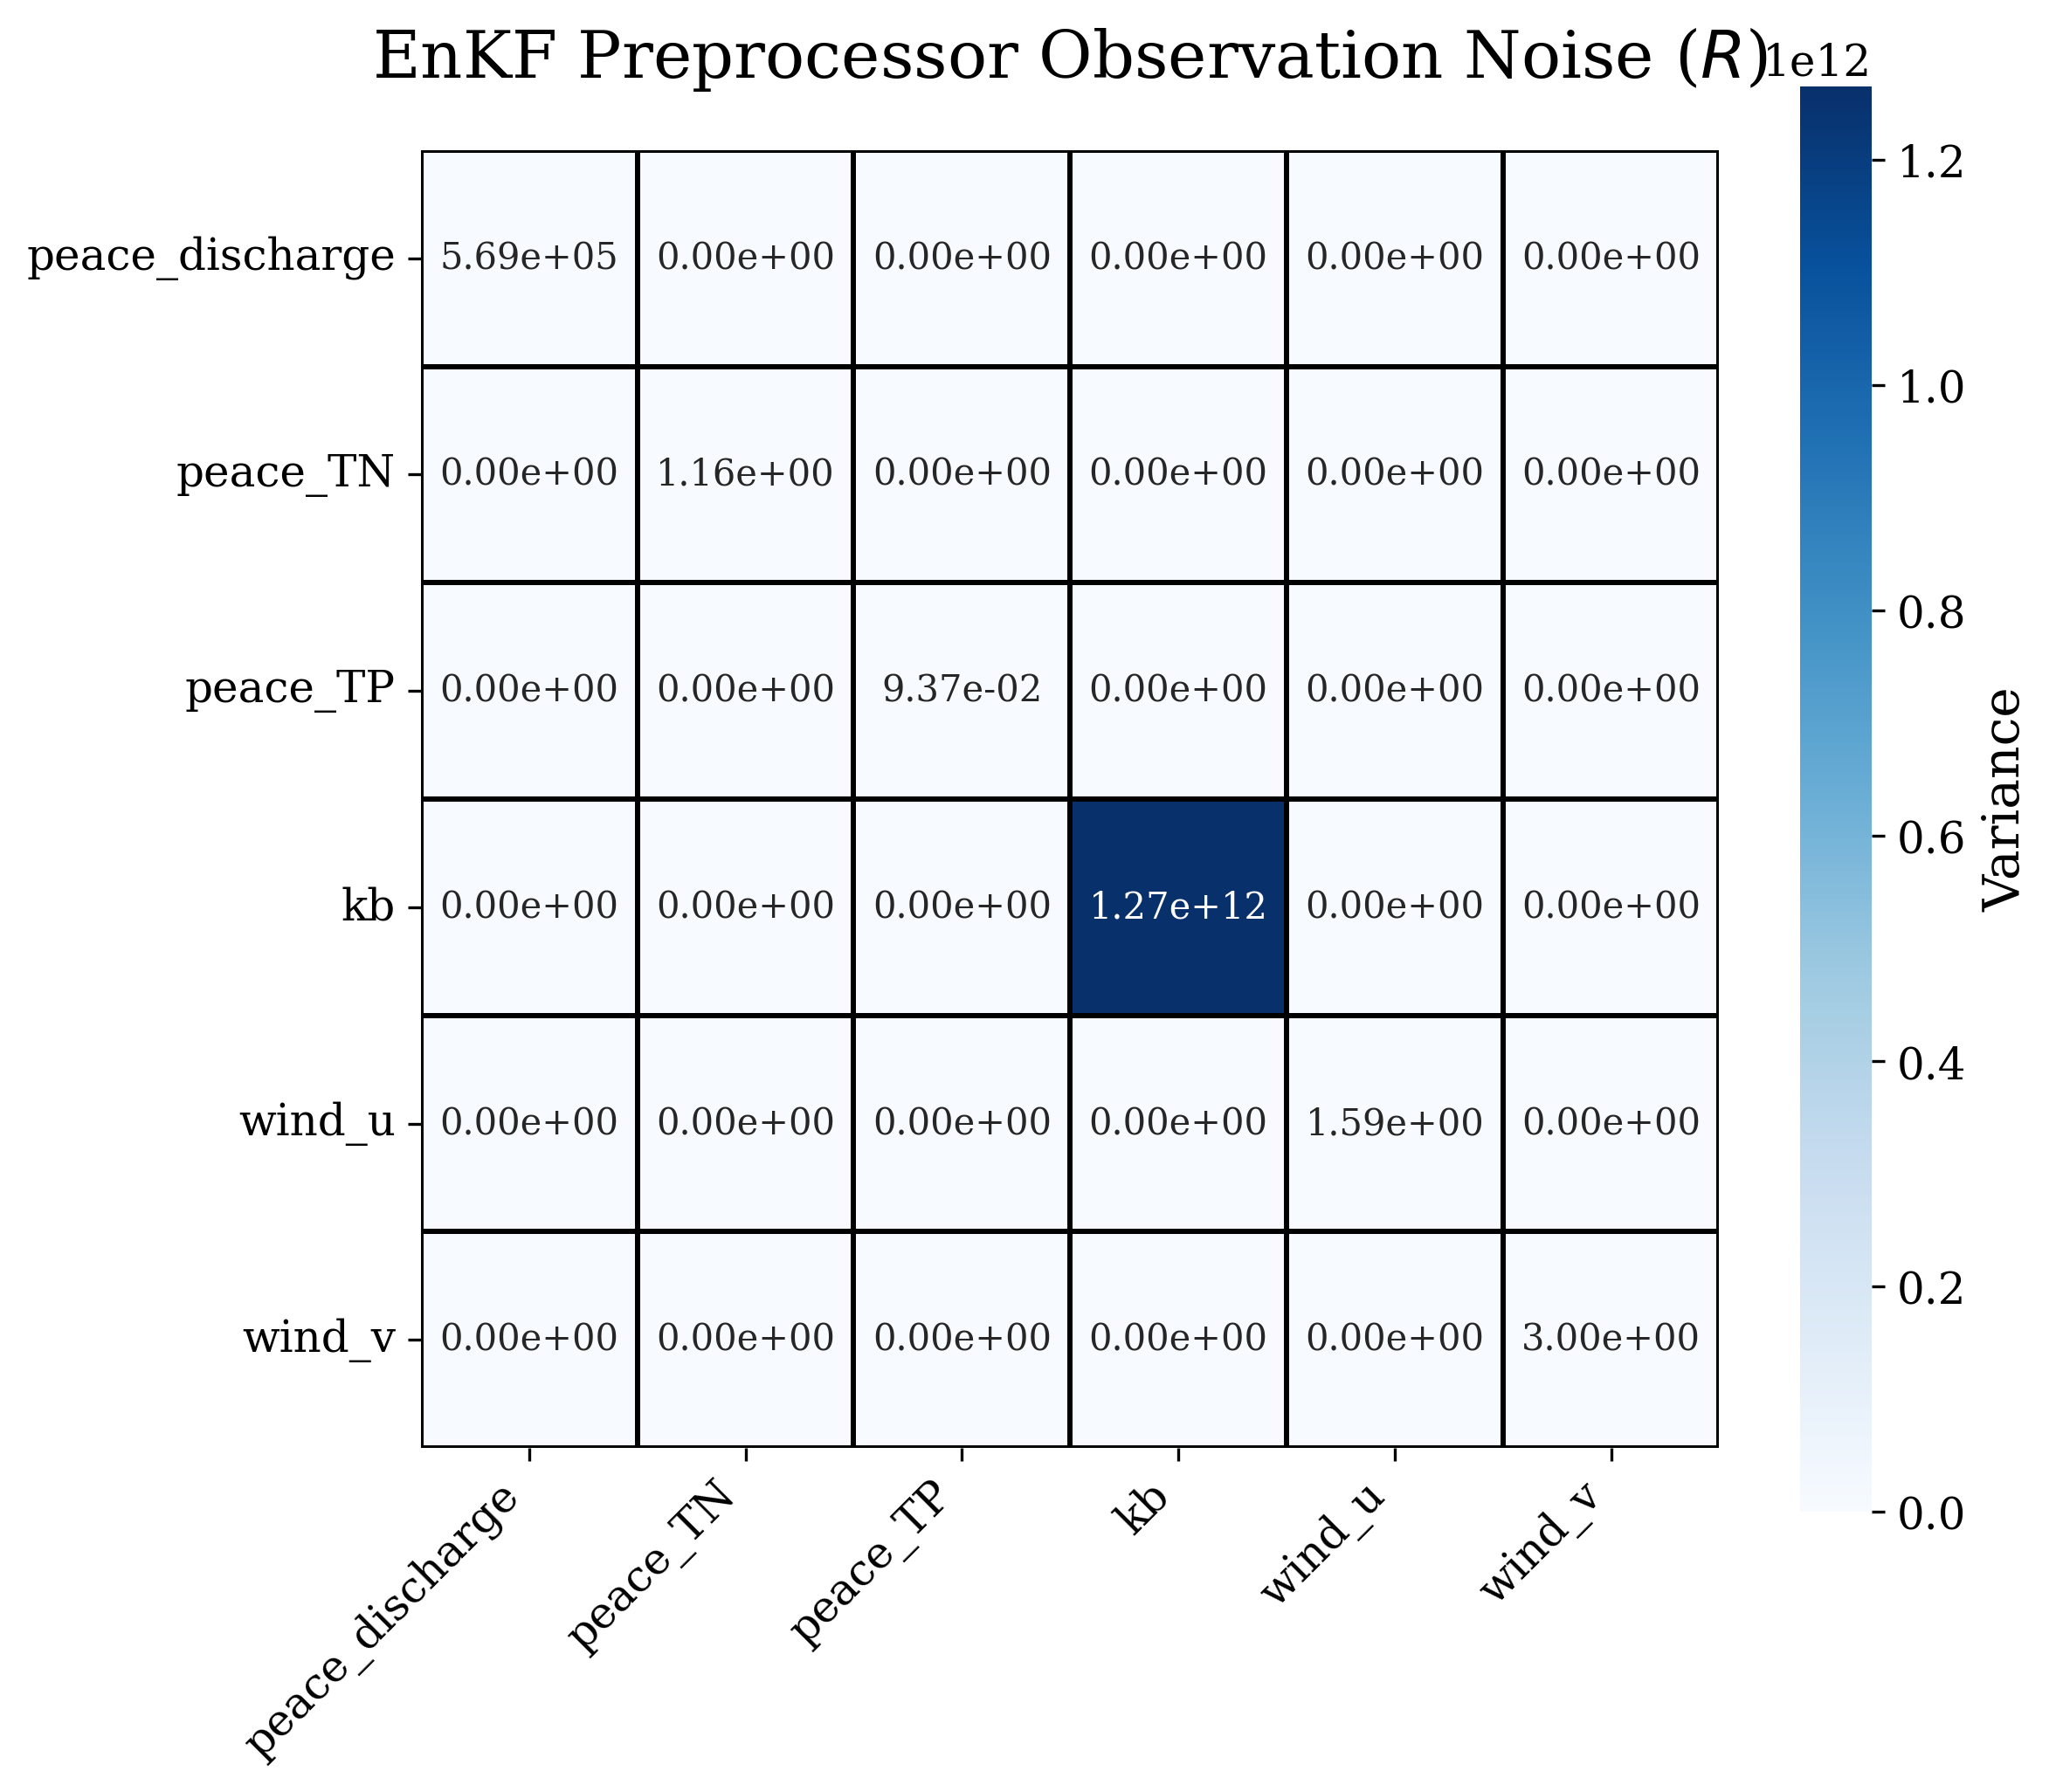

In [3]:
# --- EnKF preprocessor provenance and Q/R heatmaps ---
import seaborn as sns

with open(ENKF_PREPROCESSOR_NOISE_PATH) as f:
    enkf_noise = json.load(f)

state_vars = enkf_noise["state_vars"]
Q_matrix_enkf = np.diag(np.asarray(enkf_noise["Q_diag"], dtype=float))
R_matrix_enkf = np.diag(np.asarray(enkf_noise["R_diag"], dtype=float))

plt.rcdefaults()
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
})

def plot_covariance_matrix(matrix, title, filename, labels, cmap):
    plt.figure(figsize=(8, 7))
    sns.heatmap(matrix, annot=True, fmt=".2e", cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                square=True, cbar_kws={"label": "Variance"},
                linewidths=1, linecolor="black")
    plt.title(title, pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

plot_covariance_matrix(Q_matrix_enkf, "EnKF Preprocessor Process Noise ($Q$)", "matrix_Q_heatmap.png", state_vars, "Reds")
plot_covariance_matrix(R_matrix_enkf, "EnKF Preprocessor Observation Noise ($R$)", "matrix_R_heatmap.png", state_vars, "Blues")


## Part 14: EnKF + MC Dropout Forecasting Loop

This section implements the core forecasting engine, which synthesizes the data assimilation capabilities of the Ensemble Kalman Filter (EnKF) with the predictive power and uncertainty estimation of the LSTM. The loop iterates through the test period, sequentially updating environmental states and generating probabilistic forecasts.

### Functionality: `run_enkf_mc_forecast`

The forecasting simulation is encapsulated in the `run_enkf_mc_forecast` function, which manages the interaction between real-time observations and the deep learning model.

1. **State Assimilation (EnKF):** For each time step, the function retrieves the current observations from the unscaled test data. If `perform_enkf` is enabled, the EnKF instance performs a prediction and update step. This process corrects the hydrological state variables (such as river discharge and nutrient levels) by balancing the model's internal state with actual observed data, effectively reducing the "drift" often found in long-term time-series forecasting.
2. **Input Sequence Modification:** Once the EnKF provides an updated state, these values are passed through the fitted scaler. The function then takes the standard input sequence from `X_test` and replaces the state variables in the most recent time step with these assimilated values. This ensures the LSTM makes its next prediction based on the most accurate, ground-truth-adjusted data available.
3. **Probabilistic Prediction (MC Dropout):**
* **Uncertainty Quantification:** If `perform_mc` is active, the model performs multiple forward passes (defined by `n_mc_samples`) for the same input sequence. By keeping dropout layers active during inference (`training=True`), each pass produces a slightly different prediction, allowing us to capture the model's predictive uncertainty.
* **Standard Inference:** If MC Dropout is disabled, the model performs a standard `predict()` call, providing a single deterministic output.



### Execution and Robustness

The execution block verifies that all prerequisites—including the trained model, initialized EnKF, and noise matrices—are present before starting the loop.

* **Error Handling:** The loop is wrapped in try-except blocks to manage potential issues during matrix inversions in the EnKF or scaling errors. If a critical failure occurs, the loop captures the error and returns the results generated up to that point.
* **Result Trimming:** To maintain data integrity, both the prediction results and the corresponding ground truth labels (`y_test`) are trimmed to the exact number of successfully completed iterations.

Upon completion, the results are stored in `mc_predictions_results`. These raw probability outputs (either as single points or ensembles) serve as the foundation for the performance metrics and uncertainty analysis performed in **Part 13: EnKF + MC Dropout Evaluation**.

In [4]:
# --- MC-dropout inference for the EnKF-preprocessed LSTM ---
def mc_dropout_predict(model, X, n_samples=50, batch_size=512):
    X = np.asarray(X, dtype=np.float32)
    preds = []
    for start in range(0, len(X), batch_size):
        xb = tf.convert_to_tensor(X[start:start + batch_size], dtype=tf.float32)
        batch_preds = []
        for _ in range(n_samples):
            batch_preds.append(model(xb, training=True).numpy().reshape(-1))
        preds.append(np.stack(batch_preds, axis=1))
    return np.vstack(preds).astype(np.float32)

print(f"Running MC dropout on validation and test (N={N_MC_SAMPLES})...")
mc_val = mc_dropout_predict(model, X_val, n_samples=N_MC_SAMPLES)
val_prob = mc_val.mean(axis=1)
enkf_threshold = best_f1_threshold(y_val, val_prob)
print(f"Validation-selected threshold: {enkf_threshold:.4f}")

mc_preds = mc_dropout_predict(model, X_test, n_samples=N_MC_SAMPLES)
y_test_trimmed = np.asarray(y_test).flatten().astype(int)
enkf_hybrid_prob = mc_preds.mean(axis=1)
enkf_hybrid_std = mc_preds.std(axis=1)
print(f"mc_preds={mc_preds.shape}, y_test={y_test_trimmed.shape}")


Running MC dropout on validation and test (N=50)...
Validation-selected threshold: 0.5707
mc_preds=(216, 50), y_test=(216,)


## Part 15: EnKF + MC Dropout Evaluation

This final analytical section focuses on quantifying the performance of the integrated forecasting system. By evaluating the predictions generated in Part 12, we assess how the combination of Ensemble Kalman Filter (EnKF) state updates and Monte Carlo (MC) Dropout uncertainty estimation improves the model's ability to predict red tide events.

### Core Evaluation Components

The evaluation framework is designed to move beyond simple point-accuracy and instead provide a comprehensive view of model reliability and confidence.

1. **Ensemble Statistics and Uncertainty:**
For sessions where `PERFORM_MC_DROPOUT` was enabled, the evaluation calculates the mean and standard deviation across all MC samples for each time step. The mean serves as the primary probabilistic forecast, while the standard deviation provides a quantifiable measure of model uncertainty. This allows us to identify periods where the model is highly confident versus periods where environmental volatility leads to wider prediction intervals.
2. **Binary Classification Performance:**
Since the ultimate goal is to predict bloom occurrences, the probabilistic outputs are converted into binary classifications using an optimized threshold. Key performance metrics include:
* **Precision and Recall:** Determining the model's ability to correctly identify blooms while minimizing false alarms.
* **F1-Score:** Providing a balanced metric that accounts for the inherent class imbalance in red tide data.
* **Confusion Matrix:** Visualizing the distribution of True Positives, True Negatives, False Positives, and False Negatives.


3. **Probabilistic Analysis:**
The evaluation includes the calculation of the **Brier Score** to measure the accuracy of the probability forecasts and the **Area Under the Precision-Recall Curve (AUPRC)**. These metrics are particularly useful for evaluating models where the event of interest (the bloom) is relatively rare compared to non-bloom periods.

### Visualizing the Results

The section generates a series of diagnostic plots to illustrate the system's effectiveness:

* **Forecast vs. Actuals:** A time-series plot comparing the predicted probabilities (with uncertainty bands) against the actual observed bloom markers.
* **EnKF Impact Analysis:** Comparative visualizations showing how the state assimilation influenced the trajectory of the predictions compared to a baseline model without EnKF updates.

By the end of this evaluation, we can determine the specific "value-add" of the EnKF + MC Dropout approach, providing a clear picture of how well the hybrid system handles the complexities of ecological forecasting.


--- LSTM-EnKF preprocessor + MC dropout ---
{
  "AUC": 0.9359099804305283,
  "AUPRC": 0.8636251858768784,
  "Brier": 0.14847029745578766,
  "F1@threshold": 0.7657142857142857,
  "F1@0.5": 0.7243243243243244,
  "accuracy": 0.8101851851851852,
  "precision": 0.638095238095238,
  "recall": 0.9571428571428572,
  "threshold_used": 0.5707105398178101,
  "n_test": 216,
  "n_positive_test": 70,
  "model": "lstm_enkf_preprocessor_mc_dropout",
  "n_mc_samples": 50,
  "sequence_length": 26
}
Wrote output_refactored/predictions_enkf_mc.csv
Wrote output_refactored/intermediate\enkf_metrics.json


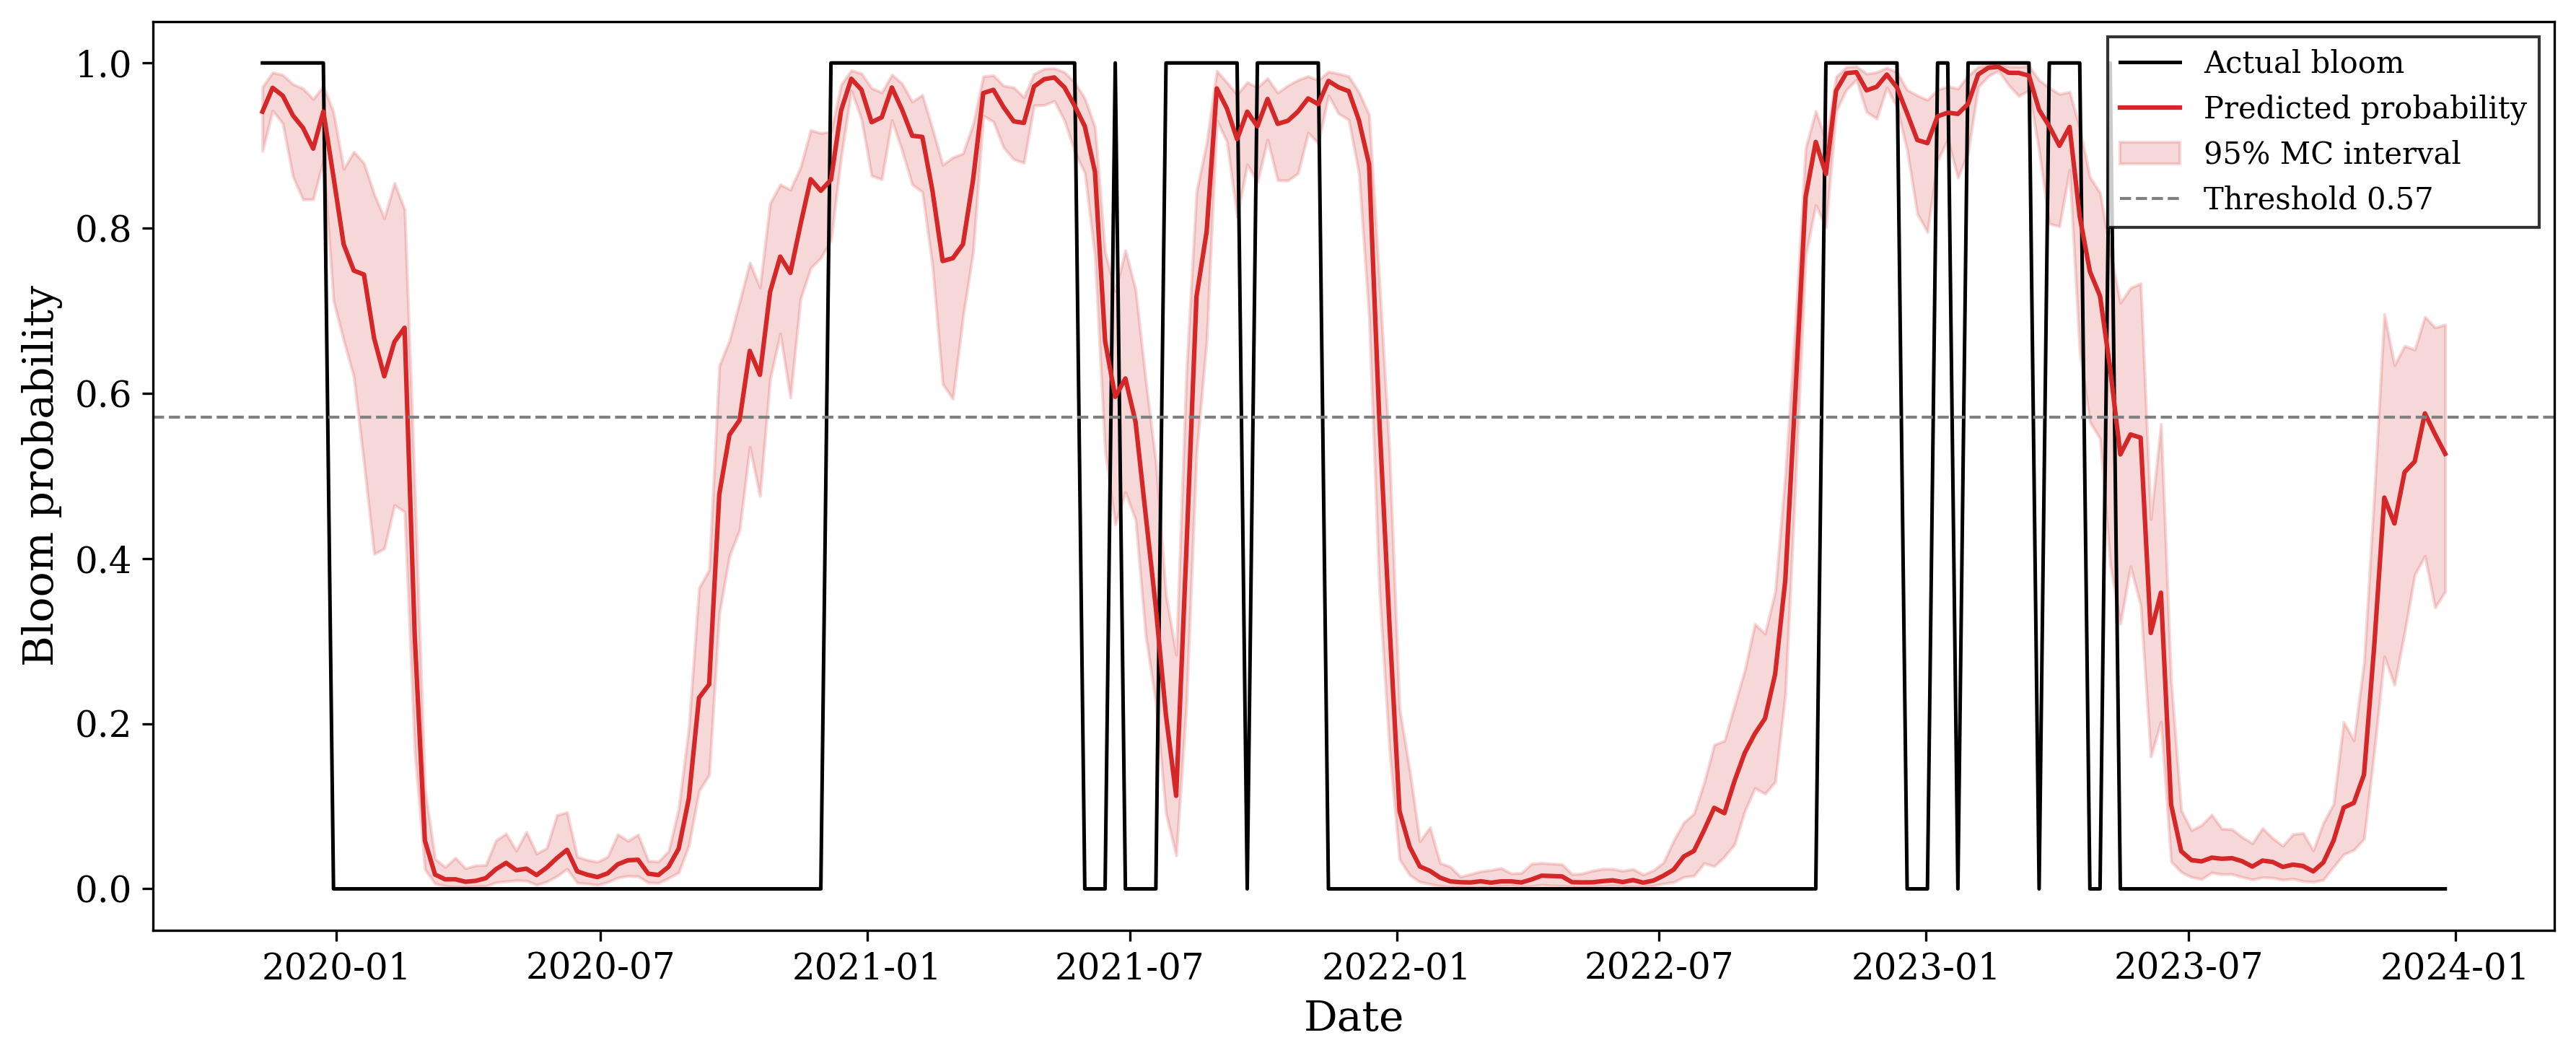

Saved: output_refactored/forecast_EnKF_LSTM_MC.png


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

metrics_enkf = evaluate_probability_stream(y_test_trimmed, enkf_hybrid_prob, threshold=enkf_threshold)
metrics_enkf.update({
    "model": "lstm_enkf_preprocessor_mc_dropout",
    "n_mc_samples": int(N_MC_SAMPLES),
    "sequence_length": int(SEQUENCE_LENGTH),
})

print("\n--- LSTM-EnKF preprocessor + MC dropout ---")
print(json.dumps(metrics_enkf, indent=2))

eps = 1e-10
p = np.clip(enkf_hybrid_prob, eps, 1 - eps)
entropy = -(p * np.log(p) + (1 - p) * np.log(1 - p))
ci_lower = np.percentile(mc_preds, 2.5, axis=1)
ci_upper = np.percentile(mc_preds, 97.5, axis=1)

start_idx = SEQUENCE_LENGTH + FORECAST_HORIZON - 1
dates = test_df.index[start_idx:start_idx + len(y_test_trimmed)]
if len(dates) != len(y_test_trimmed):
    dates = test_df.index[-len(y_test_trimmed):]

pred_df = pd.DataFrame({
    "date": dates,
    "y_actual": y_test_trimmed,
    "y_mean": enkf_hybrid_prob,
    "y_std": enkf_hybrid_std,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper,
    "entropy": entropy,
    "threshold": enkf_threshold,
}).set_index("date")

os.makedirs(OUTPUT_DIR, exist_ok=True)
pred_df.to_csv(ENKF_MC_PREDICTIONS_CSV_PATH)
write_json(ENKF_METRICS_PATH, metrics_enkf)
write_json(ENKF_MC_METRICS_JSON_PATH, metrics_enkf)

print(f"Wrote {ENKF_MC_PREDICTIONS_CSV_PATH}")
print(f"Wrote {ENKF_METRICS_PATH}")

plt.figure(figsize=(12, 5), dpi=300)
plt.plot(pred_df.index, pred_df["y_actual"], color="black", lw=1.2, label="Actual bloom")
plt.plot(pred_df.index, pred_df["y_mean"], color="#d62728", lw=1.5, label="Predicted probability")
plt.fill_between(pred_df.index, pred_df["ci_lower"], pred_df["ci_upper"],
                 color="#d62728", alpha=0.18, label="95% MC interval")
plt.axhline(enkf_threshold, color="gray", linestyle="--", lw=1, label=f"Threshold {enkf_threshold:.2f}")
plt.ylim(-0.05, 1.05)
plt.ylabel("Bloom probability")
plt.xlabel("Date")
plt.legend(frameon=True, fancybox=False, edgecolor="black")
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "forecast_EnKF_LSTM_MC.png")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## Persist MC predictions + metrics

In [6]:
# Persist arrays for notebooks 05, 07, and 08.
np.save(MC_PREDS_PATH, mc_preds.astype(np.float32))
np.save(os.path.join(INTERMEDIATE_DIR, "y_test_trimmed.npy"), y_test_trimmed.astype(np.int8))
np.save(LSTM_ENKF_TEST_PROBS_PATH, enkf_hybrid_prob.astype(np.float32))
print(f"Wrote {MC_PREDS_PATH} shape={mc_preds.shape}")
print(f"Wrote {os.path.join(INTERMEDIATE_DIR, 'y_test_trimmed.npy')} shape={y_test_trimmed.shape}")
print(f"Wrote {LSTM_ENKF_TEST_PROBS_PATH} shape={enkf_hybrid_prob.shape}")


Wrote output_refactored/intermediate\mc_predictions.npy shape=(216, 50)
Wrote output_refactored/intermediate\y_test_trimmed.npy shape=(216,)
Wrote output_refactored/intermediate\lstm_enkf_test_probs.npy shape=(216,)
